In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score ,r2_score ,confusion_matrix
from sklearn.metrics import confusion_matrix

In [2]:
sonar_data = pd.read_csv('/kaggle/input/connectionist-bench-sonar-mines-vs-rocks/sonar.all-data.csv', header=None)
dataSonarCopy=sonar_data.copy()

# sonar_data = pd.read_csv('/kaggle/input/connectionist-bench-sonar-mines-vs-rocks/sonar.all-data.csv', header=None)
# dataSonarCopy=sonar_data.copy()

In [3]:
sonar_data.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,Freq_7,Freq_8,Freq_9,Freq_10,...,Freq_52,Freq_53,Freq_54,Freq_55,Freq_56,Freq_57,Freq_58,Freq_59,Freq_60,Label
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R


In [5]:
sonar_data = sonar_data.drop(index=0).reset_index(drop=True)

In [6]:
column_names = [f'freqi-{i}' for i in range(60)] + ['target']
sonar_data.columns = column_names

In [7]:
sonar_data=pd.DataFrame(sonar_data)

In [8]:
sonar_data.shape # (209 rows, 61 columns)

(207, 61)

In [9]:
sonar_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   freqi-0   207 non-null    object
 1   freqi-1   207 non-null    object
 2   freqi-2   207 non-null    object
 3   freqi-3   207 non-null    object
 4   freqi-4   207 non-null    object
 5   freqi-5   207 non-null    object
 6   freqi-6   207 non-null    object
 7   freqi-7   207 non-null    object
 8   freqi-8   207 non-null    object
 9   freqi-9   207 non-null    object
 10  freqi-10  207 non-null    object
 11  freqi-11  207 non-null    object
 12  freqi-12  207 non-null    object
 13  freqi-13  207 non-null    object
 14  freqi-14  207 non-null    object
 15  freqi-15  207 non-null    object
 16  freqi-16  207 non-null    object
 17  freqi-17  207 non-null    object
 18  freqi-18  207 non-null    object
 19  freqi-19  207 non-null    object
 20  freqi-20  207 non-null    object
 21  freqi-21  207 no

In [10]:
sonar_data.value_counts().sum()

207

In [11]:
sonar_data['target'].value_counts()

target
M    111
R     96
Name: count, dtype: int64

In [12]:
sonar_data.describe().T 

,count,unique,top,freq
freqi-0,207,176,0.0201,5
freqi-1,207,181,0.0523,2
freqi-2,207,189,0.0289,2
freqi-3,207,180,0.0608,3
freqi-4,207,192,0.1117,2
...,...,...,...,...
freqi-56,207,120,0.0037,7
freqi-57,207,124,0.0036,6
freqi-58,207,118,0.007,6
freqi-59,207,109,0.0053,7


In [13]:
sonar_data.isnull().sum()*100/sonar_data.shape[0] # = (0*100)/(545) = (0.0)
#Finally, you are multiplying by 100 and dividing by the total number of rows to get the percentage of missing values for each column.
#This expression provides insights into the percentage of missing data in each column of your 'sonarDataSet' dataset.

freqi-0     0.0
freqi-1     0.0
freqi-2     0.0
freqi-3     0.0
freqi-4     0.0
           ... 
freqi-56    0.0
freqi-57    0.0
freqi-58    0.0
freqi-59    0.0
target      0.0
Length: 61, dtype: float64

In [14]:
sonar_data.head()

,freqi-0,freqi-1,freqi-2,freqi-3,freqi-4,freqi-5,freqi-6,freqi-7,freqi-8,freqi-9,...,freqi-51,freqi-52,freqi-53,freqi-54,freqi-55,freqi-56,freqi-57,freqi-58,freqi-59,target
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.059,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.011,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.099,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R


In [16]:
scaler = MinMaxScaler()
sonar_data.iloc[:, :-1] = scaler.fit_transform(sonar_data.iloc[:, :-1])  # Exclude the target column

In [20]:
sonar_data.head()

,freqi-0,freqi-1,freqi-2,freqi-3,freqi-4,freqi-5,freqi-6,freqi-7,freqi-8,freqi-9,...,freqi-51,freqi-52,freqi-53,freqi-54,freqi-55,freqi-56,freqi-57,freqi-58,freqi-59,target
0,0.323009,0.221603,0.272011,0.150024,0.283033,0.666756,0.574405,0.755458,0.483045,0.394537,...,0.108417,0.218182,0.111111,0.199546,0.479487,0.389205,0.105263,0.140496,0.08776,R
1,0.182153,0.246892,0.35611,0.243699,0.230028,0.585327,0.64881,0.819405,0.817859,0.869584,...,0.319544,0.418182,0.248538,0.394558,0.615385,0.889205,0.368421,0.258953,0.166282,R
2,0.062684,0.070724,0.199737,0.03495,0.034999,0.071486,0.288149,0.269239,0.077447,0.164593,...,0.161198,0.080519,0.409357,0.179138,0.176923,0.133523,0.093822,0.107438,0.256351,R
3,0.550885,0.282898,0.153088,0.079886,0.13264,0.147003,0.318182,0.531863,0.516659,0.621479,...,0.03281,0.127273,0.277778,0.235828,0.028205,0.196023,0.102975,0.292011,0.203233,R
4,0.199853,0.191599,0.086071,0.02758,0.080396,0.238646,0.316017,0.392062,0.300607,0.418418,...,0.052782,0.023377,0.081871,0.015873,0.217949,0.153409,0.05492,0.137741,0.12933,R


In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# sonar_data.iloc[:, :-1] = sonar_data.fit_transform(data.iloc[:, :-1])  # Exclude the target column

In [ ]:
sns.pairplot(sonar_data.iloc[:, :-1])
plt.suptitle('Pairplot of Features (Excluding Target Variable)', y=1.02)
plt.show()

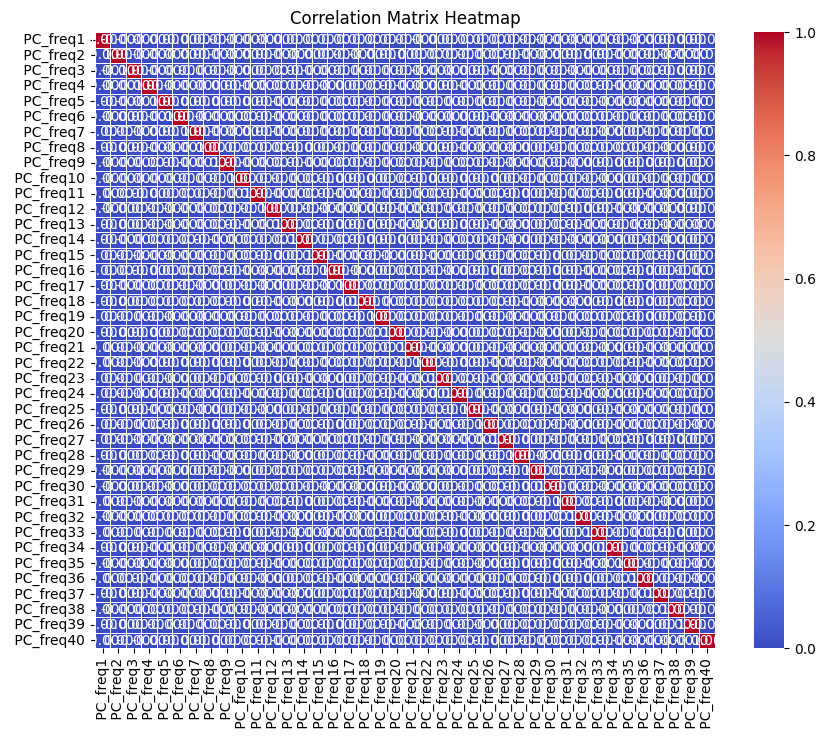

In [99]:
correlation_matrix = sonar_data.iloc[:, :-1].corr()
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')

# Add title to the heatmap
plt.title('Correlation Matrix Heatmap')
plt.show()

In [21]:
# Assuming 'sonar_data' is your DataFrame and the target column is named 'target'
X = sonar_data.drop('target', axis=1)  # Features
y = sonar_data['target']  # Target variable

# Create a RandomForestClassifier as the estimator
estimator = RandomForestClassifier()

# Create RFE selector
selector = RFE(estimator, n_features_to_select=50, step=1)

# Fit RFE selector
selector = selector.fit(X, y)

# Get selected features
selected_features = X.columns[selector.support_]

# Create new DataFrame with selected features
selected_data = sonar_data[selected_features]

In [22]:
#no the X columns become 50 with the feacture selection
# Assuming 'sonar_data' is your DataFrame and the target column is named 'target'
X = sonar_data.drop('target', axis=1)  # Features 
y = sonar_data['target']  # Target variable

# Initialize PCA with the number of components you want to keep
n_components = 40  #Adjust the number of components as needed
pca = PCA(n_components=n_components)

# Fit PCA to the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for the transformed features
column_names = [f" PC_freq{i+1}" for i in range(n_components)]  # PC1, PC2, ..., PCn
X_pca_df = pd.DataFrame(data=X_pca, columns=column_names)

# Concatenate the transformed features DataFrame with the target variable
sonar_data = pd.concat([X_pca_df, y], axis=1)

In [ ]:
X = sonar_data.drop(columns='target', axis=1)
Y = sonar_data['target']

In [ ]:
# I have alraedy done with setp early
# X=X.drop([0])
# Y=Y.drop([0])

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25,  random_state=1)
#https://www.kaggle.co

In [46]:
model = LogisticRegression()

In [47]:
model.fit(X_train, Y_train)

LogisticRegression()

In [49]:
y_pred= model.predict(X_test)

In [50]:
print(y_pred)

array(['M', 'M', 'M', 'M', 'R', 'M', 'R', 'M', 'M', 'R', 'R', 'M', 'M',
       'M', 'R', 'M', 'R', 'M', 'R', 'R', 'M', 'R', 'R', 'R', 'M', 'M',
       'R', 'M', 'R', 'M', 'R', 'M', 'M', 'R', 'R', 'R', 'R', 'M', 'R',
       'M', 'M', 'M', 'R', 'R', 'M', 'M', 'M', 'R', 'M', 'R', 'M', 'M'],
      dtype=object)

In [54]:
accuracy = accuracy_score(y_pred, Y_test) 

In [56]:
print('Accuracy on training data : ', accuracy)

Accuracy on training data :  0.7692307692307693


In [58]:
conf_matrix = confusion_matrix(Y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[22  5]
 [ 7 18]]


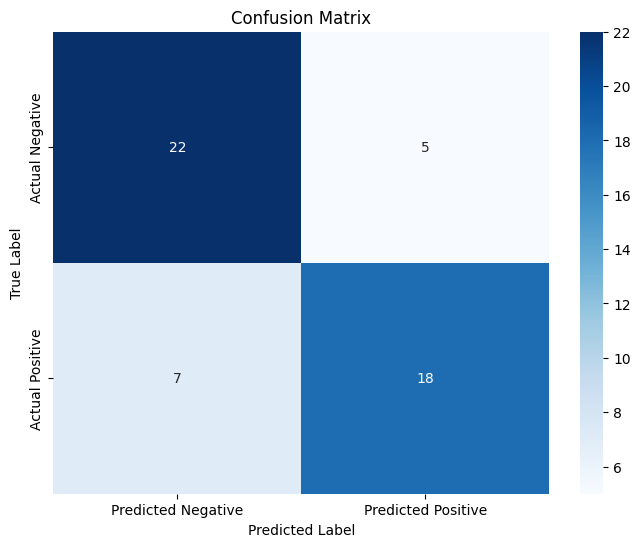

In [59]:
# Plot confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [89]:
#40 one 
input_data = (0.0307,0.0523,0.0653,0.0521,0.0611,0.0577,0.0665,0.0664,0.1460,0.2792,0.3877,0.4992,0.4981,0.4972,0.5607,0.7339,0.8230,0.9173,0.9975,0.9911,0.8240,0.6498,0.5980,0.4862,0.3150,0.1543,0.0989,0.0284,0.1008,0.2636,0.2694,0.2930,0.2925,0.3998,0.3660,0.3172,0.4609,0.4374,0.1820,0.3376)
print(len(input_data))  # Output: 40

40


In [92]:
#60 one 
input_data_as_numpy_array_and_resahped = np.asarray(input_data).reshape(1,-1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(input_data_as_numpy_array_and_resahped)

In [95]:
# # Reduce the input data to 40 elements
# input_data_40 = input_data[:40]

# # Apply MinMax scaling
# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(input_data_40)
# scaled_data=np.asarray(scaled_data).reshape(1,-1)

# print(scaled_data)

In [94]:
#prediction = model.predict(input_data_as_numpy_array_and_resahped)
prediction = model.predict(scaled_data)

print("the target Prediction from target " ,prediction)
if (prediction[0]=='R'):
  print('The object is a Rock')
else:
  print('The object is a mine')

the target Prediction from target  ['M']
The object is a mine


/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
